## Symulator tomografu komputerowego

In [28]:
from skimage import io, color
from skimage.draw import line_nd
import matplotlib.pyplot as plt
import numpy as np

#### Wczytywanie obrazu

/Users/oliwia/Library/Python/3.9/lib/python/site-packages/skimage/color/colorconv.py:984: RuntimeWarning: divide by zero encountered in matmul
  return rgb @ coeffs
/Users/oliwia/Library/Python/3.9/lib/python/site-packages/skimage/color/colorconv.py:984: RuntimeWarning: overflow encountered in matmul
  return rgb @ coeffs
/Users/oliwia/Library/Python/3.9/lib/python/site-packages/skimage/color/colorconv.py:984: RuntimeWarning: invalid value encountered in matmul
  return rgb @ coeffs


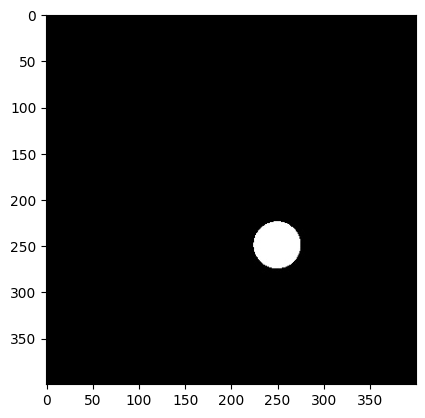

In [29]:
img = io.imread("img/Kropka.jpg")

if len(img.shape) == 3:
    img = color.rgb2gray(img)

plt.imshow(img, cmap='gray')
plt.show()

#### Transformata Radona (tworzenie sinogramu)

In [30]:
def sample_line(img, x0, y0, x1, y1):
    h, w = img.shape
    
    start = (int(round(y0)), int(round(x0)))
    end   = (int(round(y1)), int(round(x1)))

    rr, cc = line_nd(start, end)
    
    values = []
    
    for r, c in zip(rr, cc):
        if 0 <= r < h and 0 <= c < w:
            values.append(img[r, c])
    
    return np.sum(values)

In [31]:
def radon_transformation(img):
    h, w = img.shape
    cx, cy = w // 2, h // 2
    r = np.sqrt(cx**2 + cy**2)

    phi = np.pi / 2
    angles = np.deg2rad(np.arange(0, 360, alpha))

    sinogram = []

    for a in angles:
        projections = []

        xE = cx + r * np.cos(a)
        yE = cy - r * np.sin(a)

        for i in range(n):
            if i == 0:
                xD = cx + r * np.cos(a + np.pi - (phi / 2))
                yD = cy - r * np.sin(a + np.pi - (phi / 2))
            else:
                xD = cx + r * np.cos(a + np.pi - (phi / 2) + i * (phi / (n - 1)))
                yD = cy - r * np.sin(a + np.pi - (phi / 2) + i * (phi / (n - 1)))

            val = sample_line(img, xE, yE, xD, yD)
            projections.append(val)

        sinogram.append(projections)
    
    return np.array(sinogram)

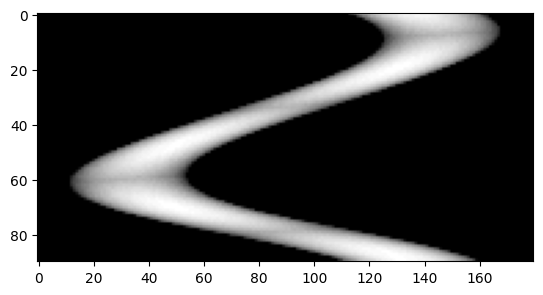

In [32]:
n = 180                 # liczba detektorów
l = 1                   # rozpiętość detektorów
alpha = 4               # krok układu
samples = 500           # liczba próbek dla linii

sinogram = radon_transformation(img)

plt.imshow(sinogram, cmap='gray')

#### Filtrowanie sinogramu

In [33]:
def filter(sinogram):
    filtered_sinogram = []
    kernel = []

    for k in range(21):
        if k == 0:
            kernel.append(1)
        elif k % 2 == 0:
            kernel.append(0)
        else:
            kernel.append((-4 / (np.pi**2)) / k**2)

    kernel = kernel[0:len(kernel) // 2]

    for i in range(len(sinogram)):
        filtered_sinogram.append(np.convolve(sinogram[i, :], kernel, mode='same'))
    
    return filtered_sinogram

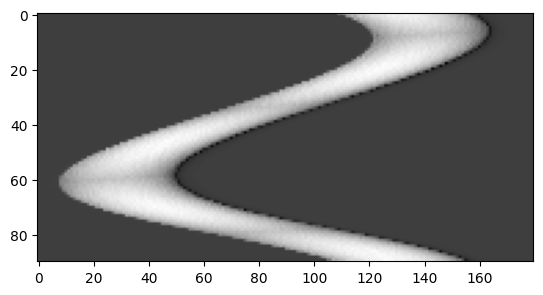

In [34]:
filtered_sinogram = filter(sinogram)

plt.imshow(filtered_sinogram, cmap='gray')

#### Odwrotna transformata Radona (rekonstrukcja obrazu)

In [35]:
def get_line(img, x0, y0, x1, y1):
    h, w = img.shape
    
    start = (int(round(y0)), int(round(x0)))
    end   = (int(round(y1)), int(round(x1)))

    rr, cc = line_nd(start, end)

    points = []
    
    for r, c in zip(rr, cc):
        if 0 <= r < h and 0 <= c < w:
            points.append((c, r))

    return points

In [36]:
def reverse_radon_transformation(img, sinogram):
    sinogram = np.array(sinogram)

    h, w = img.shape
    cx, cy = w // 2, h // 2
    r = np.sqrt(cx**2 + cy**2)

    phi = np.pi / 2
    angles = np.deg2rad(np.arange(0, 360, alpha))

    reconstruction = np.zeros((h, w))

    for ai, a in enumerate(angles):
        xE = cx + r * np.cos(a)
        yE = cy - r * np.sin(a)

        for i in range(n):
            if i == 0:
                xD = cx + r * np.cos(a + np.pi - (phi / 2))
                yD = cy - r * np.sin(a + np.pi - (phi / 2))
            else:
                xD = cx + r * np.cos(a + np.pi - (phi / 2) + i * (phi / (n - 1)))
                yD = cy - r * np.sin(a + np.pi - (phi / 2) + i * (phi / (n - 1)))

            val = sinogram[ai, i]

            line = get_line(img, xE, yE, xD, yD)

            for x, y in line:
                if 0 <= x < w and 0 <= y < h:
                    reconstruction[y, x] += val

    reconstruction /= len(angles)
    
    return reconstruction



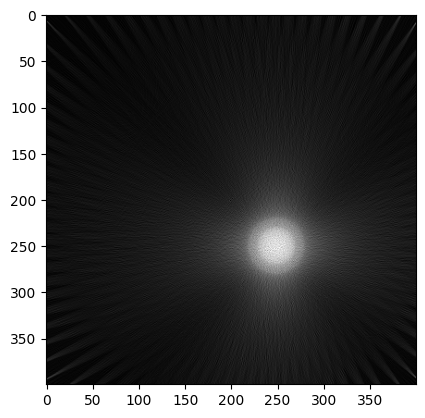

In [37]:
reconstruction = reverse_radon_transformation(img, filtered_sinogram)

plt.imshow(reconstruction, cmap='gray')